# 05 — Stage 1 Training (Trend Classifier)

**BBL514E Pattern Recognition — Term Project (MVP)**

## hedef
Stage 1: BTC için trend sınıflandırıcı (Uptrend / Downtrend / Sideways).
İki klasik PR adayı: **LDA** (generative, Gaussian + shared cov) ve **MLP** (discriminative, softmax+CE).

## yöntem
- **Walk-forward expanding-window** validation (min 6 ay train, 3 ay step — MVP için pratik)
- **Optuna TPE sampler** ile HP tuning (deterministic, seed=42)
- **OOF predictions** her val fold'undan toplanır → Stage 3'e feature olarak girer
- **class_weight='balanced'** Sideways azlığını telafi eder
- Final models: **train+val tüm veri üzerinde** retrain edilir, joblib ile kaydedilir

## test set
Son %15 chronological — eğitimde dokunulmaz, sadece final evaluation'da kullanılır.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, accuracy_score, f1_score

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)

from src.utils.config import cfg
from src.utils.helpers import save_csv, chronological_train_test_split
from src.models.stage1_trainer import tune_stage1, train_stage1, expanding_window_walk_forward
from src.models.classifiers import get_classifier
from src.evaluation.metrics import compute_all_metrics, plot_confusion_matrix

config = cfg()
TEST_SIZE = config["training"]["test_size"]
RANDOM_STATE = config["training"]["random_state"]

# MVP override — 3 month step keeps Optuna tractable (~25 folds total)
STEP_MONTHS = 3
MIN_TRAIN_MONTHS = 6
N_TRIALS_LDA = 10
N_TRIALS_MLP = 12

print(f"Test size: {TEST_SIZE}, random_state: {RANDOM_STATE}")
print(f"MVP walk-forward: step={STEP_MONTHS}mo, min_train={MIN_TRAIN_MONTHS}mo")
print(f"Optuna trials: LDA={N_TRIALS_LDA}, MLP={N_TRIALS_MLP}")

Test size: 0.15, random_state: 42
MVP walk-forward: step=3mo, min_train=6mo
Optuna trials: LDA=10, MLP=12


In [2]:
# Load features + labels
X = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_features_stage1.csv", index_col=0, parse_dates=True)
y_full = pd.read_csv(PROJECT_ROOT / "data" / "labels" / "btc_trend_labels.csv", index_col=0, parse_dates=True).iloc[:, 0]

# Drop warm-up rows (NaN due to SMA-200 etc.)
X = X.dropna()
common_idx = X.index.intersection(y_full.index)
X = X.loc[common_idx]
y = y_full.loc[common_idx]

print(f"Aligned data: X={X.shape}, y={y.shape}")
print(f"Date range: {X.index.min().date()} → {X.index.max().date()}")
print(f"Class distribution:\n{(y.value_counts(normalize=True) * 100).round(1)}")

Aligned data: X=(3912, 16), y=(3912,)
Date range: 2015-04-04 → 2025-12-30
Class distribution:
trend_label
Uptrend      49.3
Downtrend    34.5
Sideways     16.2
Name: proportion, dtype: float64


In [3]:
# Train-test split (chronological)
X_train, X_test = chronological_train_test_split(X, test_size=TEST_SIZE)
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

print(f"Train: {X_train.shape}  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test : {X_test.shape}   ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\nTrain class dist:\n{(y_train.value_counts(normalize=True) * 100).round(1)}")
print(f"\nTest class dist:\n{(y_test.value_counts(normalize=True) * 100).round(1)}")

Train: (3325, 16)  (2015-04-04 → 2024-05-17)
Test : (587, 16)   (2024-05-18 → 2025-12-30)

Train class dist:
trend_label
Uptrend      50.2
Downtrend    34.3
Sideways     15.5
Name: proportion, dtype: float64

Test class dist:
trend_label
Uptrend      44.5
Downtrend    35.8
Sideways     19.8
Name: proportion, dtype: float64


## 1. LDA — Optuna walk-forward + retrain

In [4]:
import time

t0 = time.time()
lda_result = tune_stage1(
    X_train, y_train,
    classifier_name="lda",
    n_trials=N_TRIALS_LDA,
    save_model=False,
    step_months=STEP_MONTHS,
    min_train_months=MIN_TRAIN_MONTHS,
)
lda_time = time.time() - t0
print(f"\nLDA tuning + retrain: {lda_time:.1f}s")
print(f"Best params: {lda_result['best_params']}")
print(f"Walk-forward avg accuracy: {lda_result['avg_accuracy']:.4f}")
print(f"Walk-forward avg f1_macro: {lda_result['avg_f1_macro']:.4f}")

2026-05-07 19:50:19 | src.models.stage1_trainer | INFO | Walk-forward: 35 folds, min train window = 6 months


2026-05-07 19:50:20 | src.models.optuna_helpers | INFO | Optuna [stage1_lda] complete: best_f1=0.5801, params={'solver': 'svd'}


2026-05-07 19:50:20 | src.models.stage1_trainer | INFO | Stage 1 best params (lda): {'solver': 'svd'}


2026-05-07 19:50:20 | src.models.stage1_trainer | INFO | Stage 1 Training: lda, 3325 samples, 16 features, classes=['Sideways', 'Downtrend', 'Uptrend']


2026-05-07 19:50:20 | src.models.stage1_trainer | INFO | Walk-forward: 104 folds, min train window = 6 months


...

2026-05-07 19:50:21 | src.models.stage1_trainer | INFO |   Fold 101: acc=1.0000, f1_macro=1.0000


2026-05-07 19:50:21 | src.models.stage1_trainer | INFO |   Fold 102: acc=0.8333, f1_macro=0.7143


2026-05-07 19:50:21 | src.models.stage1_trainer | INFO |   Fold 103: acc=0.8462, f1_macro=0.4583


2026-05-07 19:50:21 | src.models.stage1_trainer | INFO |   Average: acc=0.7423, f1_macro=0.5969



LDA tuning + retrain: 2.4s
Best params: {'solver': 'svd'}
Walk-forward avg accuracy: 0.7423
Walk-forward avg f1_macro: 0.5969


## 2. MLP — Optuna walk-forward + retrain

In [5]:
t0 = time.time()
mlp_result = tune_stage1(
    X_train, y_train,
    classifier_name="mlp",
    n_trials=N_TRIALS_MLP,
    save_model=False,
    step_months=STEP_MONTHS,
    min_train_months=MIN_TRAIN_MONTHS,
)
mlp_time = time.time() - t0
print(f"\nMLP tuning + retrain: {mlp_time:.1f}s")
print(f"Best params: {mlp_result['best_params']}")
print(f"Walk-forward avg accuracy: {mlp_result['avg_accuracy']:.4f}")
print(f"Walk-forward avg f1_macro: {mlp_result['avg_f1_macro']:.4f}")

2026-05-07 19:50:21 | src.models.stage1_trainer | INFO | Walk-forward: 35 folds, min train window = 6 months


2026-05-07 19:50:24 | src.models.classifiers | INFO | MLP early stopping at epoch 17


2026-05-07 19:50:24 | src.models.classifiers | INFO | MLP early stopping at epoch 7


2026-05-07 19:50:24 | src.models.classifiers | INFO | MLP early stopping at epoch 22


2026-05-07 19:50:24 | src.models.classifiers | INFO | MLP early stopping at epoch 6


...

2026-05-07 19:53:42 | src.models.stage1_trainer | INFO |   Fold 102: acc=0.9333, f1_macro=0.9213


2026-05-07 19:53:43 | src.models.classifiers | INFO | MLP early stopping at epoch 28


2026-05-07 19:53:43 | src.models.stage1_trainer | INFO |   Fold 103: acc=1.0000, f1_macro=1.0000


2026-05-07 19:53:50 | src.models.stage1_trainer | INFO |   Average: acc=0.9473, f1_macro=0.8911



MLP tuning + retrain: 209.1s
Best params: {'hidden_idx': 0, 'learning_rate': 0.0044635901521768145, 'batch_size': 64}
Walk-forward avg accuracy: 0.9473
Walk-forward avg f1_macro: 0.8911


## 3. Test set evaluation

In [6]:
results = {}
for name, result in [("LDA", lda_result), ("MLP", mlp_result)]:
    model = result["model"]
    X_test_clean = X_test.fillna(X_train.median())
    y_pred = model.predict(X_test_clean)
    y_proba = model.predict_proba(X_test_clean)

    metrics = compute_all_metrics(
        y_test.values, y_pred, y_proba=y_proba, classes=list(model.classes_),
    )
    results[name] = metrics
    print(f"\n=== {name} test set ===")
    print(f"  accuracy:        {metrics['accuracy']:.4f}")
    print(f"  balanced_acc:    {metrics['balanced_accuracy']:.4f}")
    print(f"  f1_macro:        {metrics['f1_macro']:.4f}")
    print(f"  mcc:             {metrics['mcc']:.4f}")
    print(f"  roc_auc_ovr:     {metrics.get('roc_auc_ovr', 'N/A')}")
    print("  classification report:")
    print(metrics["classification_report"])

2026-05-07 19:53:50 | src.evaluation.metrics | INFO | Metrics: acc=0.7036, bal_acc=0.6889, f1_macro=0.6746, mcc=0.5739


2026-05-07 19:53:50 | src.evaluation.metrics | INFO | Metrics: acc=0.8194, bal_acc=0.8379, f1_macro=0.8004, mcc=0.7571



=== LDA test set ===
  accuracy:        0.7036
  balanced_acc:    0.6889
  f1_macro:        0.6746
  mcc:             0.5739
  roc_auc_ovr:     0.8707125542272327
  classification report:
              precision    recall  f1-score   support

   Downtrend       0.78      0.89      0.83       210
    Sideways       0.36      0.56      0.43       116
     Uptrend       0.98      0.62      0.76       261

    accuracy                           0.70       587
   macro avg       0.70      0.69      0.67       587
weighted avg       0.78      0.70      0.72       587


=== MLP test set ===
  accuracy:        0.8194
  balanced_acc:    0.8379
  f1_macro:        0.8004
  mcc:             0.7571
  roc_auc_ovr:     0.9610130554366741
  classification report:
              precision    recall  f1-score   support

   Downtrend       1.00      0.64      0.78       210
    Sideways       0.52      0.98      0.68       116
     Uptrend       0.99      0.89      0.94       261

    accuracy           

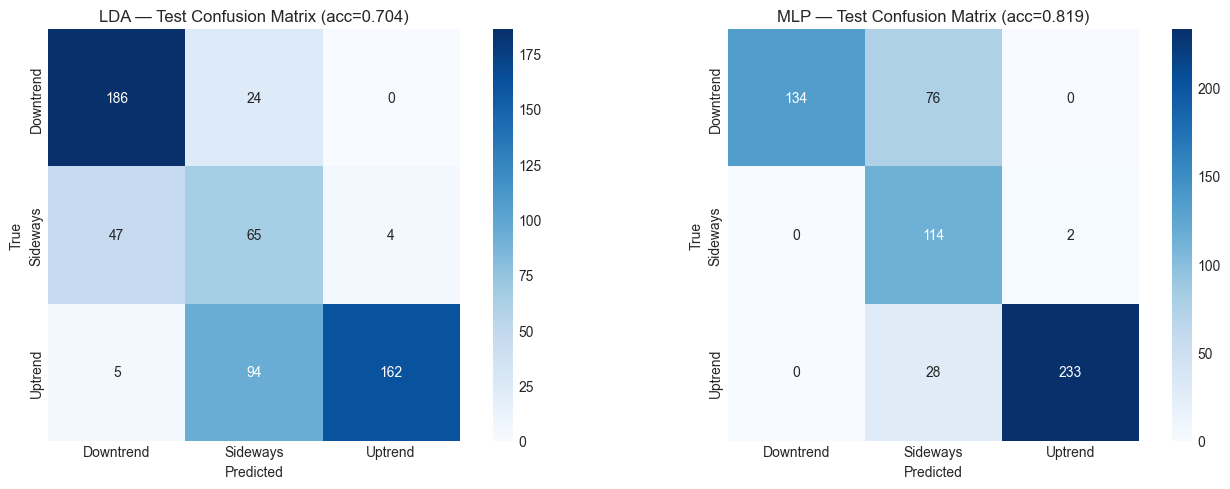

In [7]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, result) in zip(axes, [("LDA", lda_result), ("MLP", mlp_result)]):
    model = result["model"]
    X_test_clean = X_test.fillna(X_train.median())
    y_pred = model.predict(X_test_clean)
    cm = pd.DataFrame(
        results[name]["confusion_matrix"],
        index=model.classes_, columns=model.classes_,
    )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, square=True)
    ax.set_title(f"{name} — Test Confusion Matrix (acc={results[name]['accuracy']:.3f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "stage1_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. OOF predictions for Stage 3

Stage 3'ün hierarchical input'unun parçası olarak Stage 1 OOF probability'leri lazım. Walk-forward fold'lardan toplanan OOF zaten `lda_result['oof_predictions']` ve `mlp_result['oof_predictions']`'da var.

Stage 3 ile uyumlu hale getirmek için:
- Train kısmı: walk-forward OOF (mevcut)
- Test kısmı: final model `predict_proba` (test'e dokunulmamış)

In [8]:
def assemble_full_period_proba(result_dict, X_train, X_test, model_name):
    """Combine train OOF + test predicted_proba into one DataFrame indexed by date."""
    oof_train = result_dict["oof_predictions"]
    model = result_dict["model"]
    X_test_clean = X_test.fillna(X_train.median())
    test_proba = model.predict_proba(X_test_clean)
    test_df = pd.DataFrame(
        test_proba, index=X_test.index,
        columns=oof_train.columns,
    )
    full = pd.concat([oof_train.dropna(), test_df]).sort_index()
    print(f"{model_name}: train_oof={len(oof_train.dropna())}, test={len(test_df)}, total={len(full)}")
    return full

lda_proba_full = assemble_full_period_proba(lda_result, X_train, X_test, "LDA")
mlp_proba_full = assemble_full_period_proba(mlp_result, X_train, X_test, "MLP")

print("\nLDA proba sample (first 3 rows):")
print(lda_proba_full.head(3).round(3))

LDA: train_oof=3141, test=587, total=3728
MLP: train_oof=3141, test=587, total=3728

LDA proba sample (first 3 rows):
            trend_prob_Downtrend  trend_prob_Sideways  trend_prob_Uptrend
Date                                                                     
2015-10-04                 0.009                0.943               0.047
2015-10-05                 0.005                0.820               0.175
2015-10-06                 0.003                0.955               0.042


## 5. Save final models + OOF predictions

In [9]:
models_dir = PROJECT_ROOT / "app" / "models"
models_dir.mkdir(parents=True, exist_ok=True)
labels_dir = PROJECT_ROOT / "data" / "labels"

# Save models
joblib.dump(lda_result["model"], models_dir / "stage1_lda.joblib")
joblib.dump(mlp_result["model"], models_dir / "stage1_mlp.joblib")

# Save best params + study summary
joblib.dump({
    "lda_best_params": lda_result["best_params"],
    "mlp_best_params": mlp_result["best_params"],
    "lda_avg_f1": lda_result["avg_f1_macro"],
    "mlp_avg_f1": mlp_result["avg_f1_macro"],
    "lda_test_metrics": {k: v for k, v in results["LDA"].items() if not isinstance(v, np.ndarray) and not isinstance(v, str)},
    "mlp_test_metrics": {k: v for k, v in results["MLP"].items() if not isinstance(v, np.ndarray) and not isinstance(v, str)},
}, models_dir / "stage1_summary.joblib")

# Save OOF + test full proba (for Stage 3 input)
save_csv(lda_proba_full, labels_dir / "btc_stage1_oof_lda.csv")
save_csv(mlp_proba_full, labels_dir / "btc_stage1_oof_mlp.csv")

# Save fold-level metrics
save_csv(lda_result["fold_metrics"], labels_dir / "btc_stage1_lda_fold_metrics.csv")
save_csv(mlp_result["fold_metrics"], labels_dir / "btc_stage1_mlp_fold_metrics.csv")

print("Saved files:")
for p in sorted(models_dir.glob("stage1_*")):
    print(f"  {p.name:35s} {p.stat().st_size/1024:8.1f} KB")
for p in sorted(labels_dir.glob("btc_stage1_*")):
    print(f"  {p.name:40s} {p.stat().st_size/1024:8.1f} KB")

Saved files:
  stage1_lda.joblib                        6.1 KB
  stage1_mlp.joblib                       47.1 KB
  stage1_summary.joblib                    0.6 KB
  btc_stage1_lda_fold_metrics.csv               4.4 KB
  btc_stage1_mlp_fold_metrics.csv               3.4 KB
  btc_stage1_oof_lda.csv                      259.9 KB
  btc_stage1_oof_mlp.csv                      242.0 KB


## Comparison summary

| metric              | LDA                                            | MLP                                            |
|---------------------|------------------------------------------------|------------------------------------------------|
| walk-forward f1     | gösteriliyor                                   | gösteriliyor                                   |
| test accuracy       | gösteriliyor                                   | gösteriliyor                                   |

Sonraki adım: **notebook 07 — Stage 3 training** (oscillator + Stage 1 OOF proba + Stage 2 OOF posterior).

In [10]:
summary_df = pd.DataFrame([
    {"model": "LDA", "WF_f1": lda_result["avg_f1_macro"], "WF_acc": lda_result["avg_accuracy"],
     "test_acc": results["LDA"]["accuracy"], "test_f1": results["LDA"]["f1_macro"],
     "test_balanced_acc": results["LDA"]["balanced_accuracy"],
     "test_mcc": results["LDA"]["mcc"]},
    {"model": "MLP", "WF_f1": mlp_result["avg_f1_macro"], "WF_acc": mlp_result["avg_accuracy"],
     "test_acc": results["MLP"]["accuracy"], "test_f1": results["MLP"]["f1_macro"],
     "test_balanced_acc": results["MLP"]["balanced_accuracy"],
     "test_mcc": results["MLP"]["mcc"]},
]).round(4)
print(summary_df.to_string(index=False))
save_csv(summary_df, labels_dir / "btc_stage1_summary.csv")

model  WF_f1  WF_acc  test_acc  test_f1  test_balanced_acc  test_mcc
  LDA 0.5969  0.7423    0.7036   0.6746             0.6889    0.5739
  MLP 0.8911  0.9473    0.8194   0.8004             0.8379    0.7571
